# Modèle KNN — Prédiction de DIFF

Objectif : prédire si une exploitation agricole est saine (`DIFF = 1`) ou défaillante (`DIFF = 0`).

Critère principal : **AUC (ROC-AUC)** avec **validation croisée stratifiée à 5 folds**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report


## 1. Chargement des données


In [4]:
farms_train = pd.read_csv("farms_train.csv")
farms_test = pd.read_csv("farms_test.csv")
ex_soumission = pd.read_csv("ex_soumission.csv")

print("Dimensions du train :", farms_train.shape)
print("Dimensions du test :", farms_test.shape)
farms_train.head()


Dimensions du train : (400, 8)
Dimensions du test : (120, 7)


,DIFF,TOF,AGE,R7,R8,R17,R22,R32
0,1,1,50,0.613,0.19960,0.0425,0.8637,0.2882
1,0,3,40,0.856,0.87970,0.0599,0.6241,0.0917
2,0,3,61,0.396,0.08729,0.0748,0.3028,0.3447
3,0,3,49,0.665,0.39470,0.1100,0.7716,0.2397
4,0,3,47,0.565,0.10440,0.0754,0.3295,0.2094


## 2. Exploration rapide


In [5]:
farms_train.info()

print("\nValeurs manquantes :")
print(farms_train.isnull().sum())

print("\nRépartition de DIFF :")
print(farms_train["DIFF"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DIFF    400 non-null    int64  
 1   TOF     400 non-null    int64  
 2   AGE     400 non-null    int64  
 3   R7      400 non-null    float64
 4   R8      400 non-null    float64
 5   R17     400 non-null    float64
 6   R22     400 non-null    float64
 7   R32     400 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 25.1 KB

Valeurs manquantes :
DIFF    0
TOF     0
AGE     0
R7      0
R8      0
R17     0
R22     0
R32     0
dtype: int64

Répartition de DIFF :
DIFF
1    200
0    200
Name: count, dtype: int64


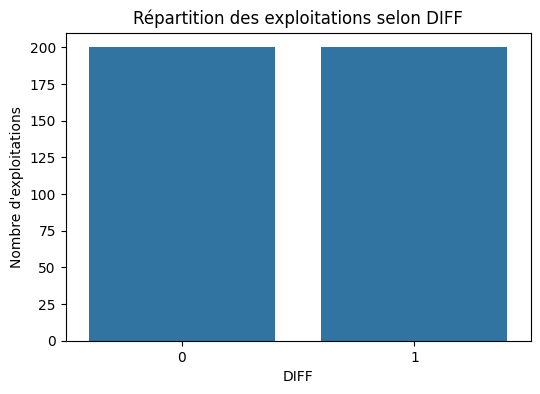

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=farms_train, x="DIFF")
plt.title("Répartition des exploitations selon DIFF")
plt.xlabel("DIFF")
plt.ylabel("Nombre d'exploitations")
plt.show()


## 3. Séparation X / y


In [7]:
X = farms_train.drop(columns="DIFF")
y = farms_train["DIFF"]

print("Dimensions X :", X.shape)
print("Dimensions y :", y.shape)
print("Variables utilisées :", X.columns.tolist())


Dimensions X : (400, 7)
Dimensions y : (400,)
Variables utilisées : ['TOF', 'AGE', 'R7', 'R8', 'R17', 'R22', 'R32']


## 4. Validation croisée stratifiée à 5 folds

La standardisation est placée dans la Pipeline pour éviter toute fuite de données entre les folds.


In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


## 5. KNN de départ avec K = 3


In [9]:
model_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

scores_auc = cross_val_score(
    model_knn, X, y, cv=cv, scoring="roc_auc"
)

print("AUC de chaque fold :", scores_auc)
print("AUC moyenne :", scores_auc.mean())
print("Écart-type :", scores_auc.std())


AUC de chaque fold : [0.8459375 0.8165625 0.830625  0.815625  0.725625 ]
AUC moyenne : 0.806875
Écart-type : 0.04209967710683778


## 6. Recherche du meilleur K selon l'AUC


In [10]:
k_values = range(1, 31)
auc_mean = []
auc_std = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        model, X, y, cv=cv, scoring="roc_auc"
    )

    auc_mean.append(scores.mean())
    auc_std.append(scores.std())

results_knn = pd.DataFrame({
    "K": list(k_values),
    "AUC_moyenne": auc_mean,
    "AUC_ecart_type": auc_std
})

display(results_knn)

best_index = np.argmax(auc_mean)
best_k = list(k_values)[best_index]
best_auc = auc_mean[best_index]

print("Meilleur K :", best_k)
print("Meilleure AUC moyenne :", best_auc)


,K,AUC_moyenne,AUC_ecart_type
0,1,0.722500,0.034821
1,2,0.783813,0.043504
2,3,0.806875,0.042100
3,4,0.832500,0.048154
4,5,0.845313,0.046459
5,6,0.850500,0.048744
6,7,0.855250,0.047971
7,8,0.855250,0.045138
8,9,0.859688,0.038572
9,10,0.860938,0.042560


Meilleur K : 27
Meilleure AUC moyenne : 0.8764999999999998


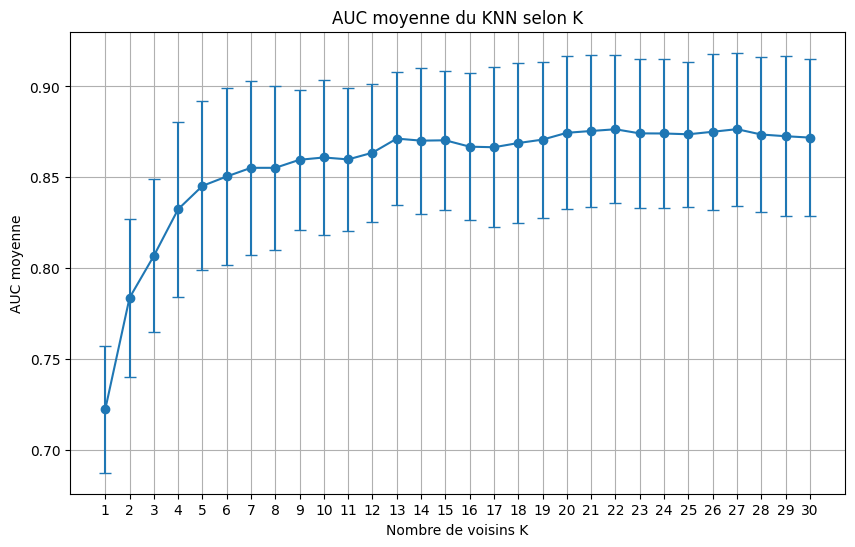

In [11]:
plt.figure(figsize=(10, 6))
plt.errorbar(
    list(k_values), auc_mean, yerr=auc_std,
    marker="o", capsize=4
)
plt.xlabel("Nombre de voisins K")
plt.ylabel("AUC moyenne")
plt.title("AUC moyenne du KNN selon K")
plt.xticks(list(k_values))
plt.grid()
plt.show()


## 7. Évaluation du meilleur KNN


In [12]:
best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

best_scores = cross_val_score(
    best_knn, X, y, cv=cv, scoring="roc_auc"
)

for i, score in enumerate(best_scores, start=1):
    print(f"Fold {i} : {score:.4f}")

print(f"\nAUC moyenne : {best_scores.mean():.4f}")
print(f"Écart-type : {best_scores.std():.4f}")


Fold 1 : 0.9156
Fold 2 : 0.8691
Fold 3 : 0.8653
Fold 4 : 0.9250
Fold 5 : 0.8075

AUC moyenne : 0.8765
Écart-type : 0.0420


## 8. Courbe ROC en validation croisée


AUC validation croisée : 0.8740375


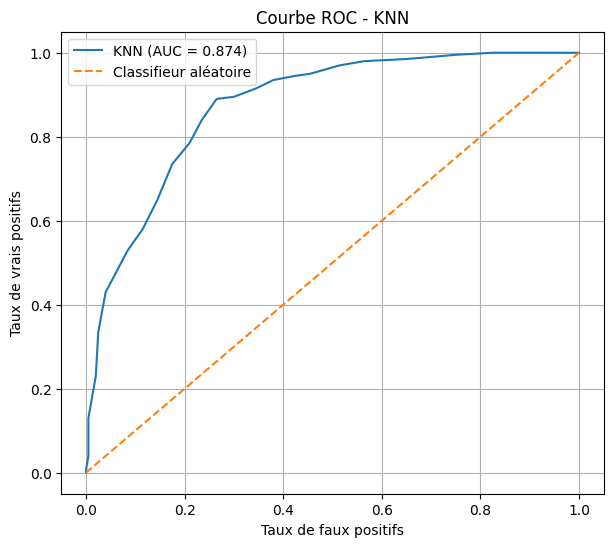

In [13]:
y_proba_cv = cross_val_predict(
    best_knn, X, y, cv=cv, method="predict_proba"
)[:, 1]

auc_cv = roc_auc_score(y, y_proba_cv)
fpr, tpr, thresholds = roc_curve(y, y_proba_cv)

print("AUC validation croisée :", auc_cv)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"KNN (AUC = {auc_cv:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Classifieur aléatoire")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - KNN")
plt.legend()
plt.grid()
plt.show()


## 9. Matrice de confusion et classification report

Ces indicateurs sont complémentaires. Le critère officiel de sélection reste l'AUC.


              precision    recall  f1-score   support

           0       0.87      0.73      0.80       200
           1       0.77      0.89      0.83       200

    accuracy                           0.81       400
   macro avg       0.82      0.81      0.81       400
weighted avg       0.82      0.81      0.81       400



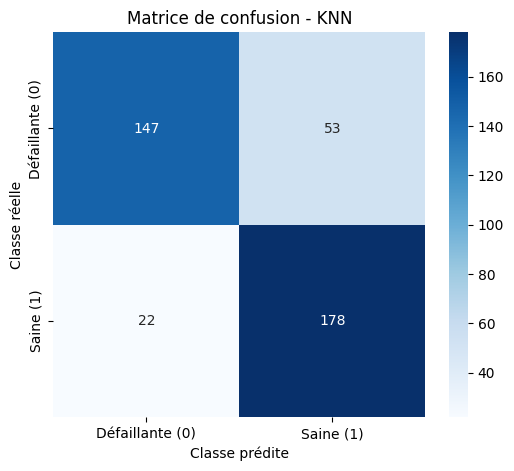

In [14]:
y_pred_cv = (y_proba_cv >= 0.5).astype(int)

print(classification_report(y, y_pred_cv))

cm = confusion_matrix(y, y_pred_cv)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Défaillante (0)", "Saine (1)"],
    yticklabels=["Défaillante (0)", "Saine (1)"]
)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion - KNN")
plt.show()


## 10. Entraînement final sur toutes les données d'apprentissage


In [15]:
best_knn.fit(X, y)
print("Modèle KNN final entraîné avec K =", best_k)


Modèle KNN final entraîné avec K = 27


## 11. Prédictions sur farms_test.csv


In [16]:
X_test = farms_test.copy()

y_test_proba = best_knn.predict_proba(X_test)[:, 1]

print("Premières probabilités DIFF = 1 :")
print(y_test_proba[:10])


Premières probabilités DIFF = 1 :
[0.22222222 0.66666667 0.77777778 0.66666667 0.77777778 0.85185185
 0.40740741 0.03703704 0.74074074 0.25925926]


## 12. Création du fichier de soumission

Pour l'AUC, on soumet les scores/probabilités associés à `DIFF = 1` plutôt que des classes 0/1.


In [17]:
submission_knn = pd.DataFrame({
    "ID": ex_soumission["ID"],
    "DIFF": y_test_proba
})

print(submission_knn.head())
print("Dimensions :", submission_knn.shape)

submission_knn.to_csv("soumission_KNN.csv", index=False)
print("Fichier soumission_KNN.csv créé !")


   ID      DIFF
0   1  0.222222
1   2  0.666667
2   3  0.777778
3   4  0.666667
4   5  0.777778
Dimensions : (120, 2)
Fichier soumission_KNN.csv créé !


In [18]:
submission_check = pd.read_csv("soumission_KNN.csv")
print(submission_check.head(10))
print("Dimensions :", submission_check.shape)
print(submission_check["DIFF"].describe())


   ID      DIFF
0   1  0.222222
1   2  0.666667
2   3  0.777778
3   4  0.666667
4   5  0.777778
5   6  0.851852
6   7  0.407407
7   8  0.037037
8   9  0.740741
9  10  0.259259
Dimensions : (120, 2)
count    120.000000
mean       0.536728
std        0.271699
min        0.000000
25%        0.324074
50%        0.574074
75%        0.777778
max        0.962963
Name: DIFF, dtype: float64
